# Análise Exploratória de Dados — E-commerce Olist

## Contexto e objetivo

Este notebook apresenta a exploração inicial da base pública de comércio eletrônico da Olist. O objetivo é conhecer a estrutura dos dados, verificar sua qualidade e preparar as informações para análises de vendas, clientes, produtos, pagamentos e entregas.

**Fonte dos dados:** Brazilian E-Commerce Public Dataset by Olist, disponível no Kaggle.

**Objetivo desta etapa:** carregar as tabelas, identificar suas dimensões, conhecer as colunas e verificar valores ausentes e registros duplicados.


## 1. Configuração e importação das bibliotecas

Nesta etapa, importaremos as bibliotecas necessárias e definiremos o caminho da pasta que contém os dados brutos.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
CAMINHO_DADOS = Path("../data/raw")

arquivos_csv = sorted(CAMINHO_DADOS.glob("*.csv"))

print(f"Quantidade de arquivos encontrados: {len(arquivos_csv)}")

for arquivo in arquivos_csv:
    print("-", arquivo.name)

Quantidade de arquivos encontrados: 9
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_orders_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- product_category_name_translation.csv


## 2. Carregamento das tabelas

Os arquivos CSV serão carregados em DataFrames do Pandas. Cada DataFrame representa uma tabela do conjunto de dados da Olist.

### 2.1 Leitura dos arquivos CSV

In [4]:
clientes = pd.read_csv(CAMINHO_DADOS / "olist_customers_dataset.csv")
geolocalizacao = pd.read_csv(CAMINHO_DADOS / "olist_geolocation_dataset.csv")
itens_pedido = pd.read_csv(CAMINHO_DADOS / "olist_order_items_dataset.csv")
pagamentos = pd.read_csv(CAMINHO_DADOS / "olist_order_payments_dataset.csv")
avaliacoes = pd.read_csv(CAMINHO_DADOS / "olist_order_reviews_dataset.csv")
pedidos = pd.read_csv(CAMINHO_DADOS / "olist_orders_dataset.csv")
produtos = pd.read_csv(CAMINHO_DADOS / "olist_products_dataset.csv")
vendedores = pd.read_csv(CAMINHO_DADOS / "olist_sellers_dataset.csv")
categorias_traducao = pd.read_csv(
    CAMINHO_DADOS / "product_category_name_translation.csv"
)

print("As nove tabelas foram carregadas com sucesso!")

As nove tabelas foram carregadas com sucesso!


### 2.2 Dimensões das tabelas

A dimensão de uma tabela informa sua quantidade de linhas e colunas. Essa verificação ajuda a compreender o tamanho e a estrutura de cada conjunto de dados.

In [5]:
tabelas = {
    "clientes": clientes,
    "geolocalizacao": geolocalizacao,
    "itens_pedido": itens_pedido,
    "pagamentos": pagamentos,
    "avaliacoes": avaliacoes,
    "pedidos": pedidos,
    "produtos": produtos,
    "vendedores": vendedores,
    "categorias_traducao": categorias_traducao,
}

resumo_dimensoes = pd.DataFrame(
    [
        {
            "tabela": nome,
            "linhas": dataframe.shape[0],
            "colunas": dataframe.shape[1],
        }
        for nome, dataframe in tabelas.items()
    ]
).sort_values("linhas", ascending=False).reset_index(drop=True)

resumo_dimensoes

,tabela,linhas,colunas
0,geolocalizacao,1000163,5
1,itens_pedido,112650,7
2,pagamentos,103886,5
3,clientes,99441,5
4,pedidos,99441,8
5,avaliacoes,99224,7
6,produtos,32951,9
7,vendedores,3095,4
8,categorias_traducao,71,2


**Interpretação inicial:** a tabela de geolocalização é a maior base do conjunto de dados. As tabelas de itens e pagamentos possuem mais registros que a tabela de pedidos, indicando que um mesmo pedido pode estar relacionado a vários produtos ou registros de pagamento. Essas relações serão verificadas nas próximas etapas.

## 3. Conhecendo a tabela de pedidos

A tabela de pedidos será examinada inicialmente porque conecta clientes, pagamentos, avaliações e itens vendidos.

In [6]:
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
pedidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


**Interpretação:** a tabela de pedidos possui 99.441 registros e 8 colunas. As colunas de data foram inicialmente carregadas como texto e precisarão ser convertidas. Também foram identificados valores ausentes nas datas de aprovação e entrega. Antes de tratar esses valores, será necessário verificar sua relação com a situação de cada pedido.

### 3.1 Verificação de valores ausentes

A quantidade e o percentual de valores ausentes serão calculados para cada coluna da tabela de pedidos.

In [8]:
quantidade_ausentes = pedidos.isna().sum()

percentual_ausentes = (
    quantidade_ausentes / len(pedidos) * 100
).round(2)

resumo_ausentes = pd.DataFrame(
    {
        "quantidade_ausentes": quantidade_ausentes,
        "percentual_ausentes": percentual_ausentes,
    }
)

resumo_ausentes = resumo_ausentes[
    resumo_ausentes["quantidade_ausentes"] > 0
].sort_values("quantidade_ausentes", ascending=False)

resumo_ausentes

,quantidade_ausentes,percentual_ausentes
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


**Resultado inicial:** a maior proporção de valores ausentes está na data de entrega ao cliente, correspondendo a 2,98% dos pedidos. Esses registros não serão removidos antes de verificarmos se a ausência está associada a pedidos cancelados, indisponíveis ou ainda não entregues.

### 3.2 Relação entre ausência da entrega e situação do pedido

Será analisada a situação dos pedidos que não possuem uma data de entrega ao cliente.

In [9]:
status_sem_entrega = (
    pedidos.loc[
        pedidos["order_delivered_customer_date"].isna(),
        "order_status",
    ]
    .value_counts()
    .rename_axis("situacao_pedido")
    .reset_index(name="quantidade")
)

status_sem_entrega["percentual"] = (
    status_sem_entrega["quantidade"]
    / status_sem_entrega["quantidade"].sum()
    * 100
).round(2)

status_sem_entrega

,situacao_pedido,quantidade,percentual
0,shipped,1107,37.34
1,canceled,619,20.88
2,unavailable,609,20.54
3,invoiced,314,10.59
4,processing,301,10.15
5,delivered,8,0.27
6,created,5,0.17
7,approved,2,0.07


**Interpretação:** a ausência da data de entrega está majoritariamente associada a pedidos que ainda estavam em processamento, haviam sido enviados, foram cancelados ou ficaram indisponíveis. Portanto, a maior parte dos valores ausentes possui uma explicação relacionada ao processo do pedido e não deve ser tratada automaticamente como erro.

Foram encontrados apenas 8 pedidos classificados como entregues sem a respectiva data de entrega. Esses casos representam uma possível inconsistência de qualidade dos dados e deverão ser analisados separadamente.

### 3.3 Verificação de registros duplicados

A próxima análise verificará se existem linhas completamente duplicadas ou identificadores de pedidos repetidos.

In [10]:
linhas_duplicadas = pedidos.duplicated().sum()
ids_pedido_duplicados = pedidos["order_id"].duplicated().sum()

resumo_duplicados = pd.DataFrame(
    {
        "verificacao": [
            "Linhas completamente duplicadas",
            "Identificadores de pedido duplicados",
        ],
        "quantidade": [
            linhas_duplicadas,
            ids_pedido_duplicados,
        ],
    }
)

resumo_duplicados

,verificacao,quantidade
0,Linhas completamente duplicadas,0
1,Identificadores de pedido duplicados,0


**Resultado:** não foram encontrados registros completamente duplicados nem identificadores de pedido repetidos. Isso confirma que cada linha representa um pedido distinto e que `order_id` pode ser utilizado como chave única da tabela.

## 4. Preparação dos dados

### 4.1 Conversão das colunas de data

As datas foram carregadas originalmente como texto. Elas serão convertidas para o tipo `datetime`, permitindo calcular períodos, prazos de entrega e evolução temporal das vendas.

In [11]:
colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for coluna in colunas_data:
    pedidos[coluna] = pd.to_datetime(
        pedidos[coluna],
        errors="coerce",
    )

pedidos[colunas_data].dtypes.to_frame(name="tipo_de_dado")

,tipo_de_dado
order_purchase_timestamp,datetime64[us]
order_approved_at,datetime64[us]
order_delivered_carrier_date,datetime64[us]
order_delivered_customer_date,datetime64[us]
order_estimated_delivery_date,datetime64[us]


**Resultado:** as cinco colunas temporais foram convertidas com sucesso para o tipo `datetime`. A partir dessa conversão, será possível calcular o tempo de entrega, comparar a entrega real com a estimativa e analisar a evolução dos pedidos ao longo do tempo.


## 5. Indicadores iniciais de pedidos

### 5.1 Período analisado e situação dos pedidos

Nesta etapa serão calculados o período coberto pela base, o total de pedidos e a distribuição dos pedidos por situação.

In [12]:
data_inicial = pedidos["order_purchase_timestamp"].min()
data_final = pedidos["order_purchase_timestamp"].max()

total_pedidos = pedidos["order_id"].nunique()
pedidos_entregues = (
    pedidos["order_status"] == "delivered"
).sum()

taxa_entrega = (
    pedidos_entregues / total_pedidos * 100
)

indicadores_pedidos = pd.DataFrame(
    {
        "indicador": [
            "Data inicial",
            "Data final",
            "Total de pedidos",
            "Pedidos entregues",
            "Taxa de entrega",
        ],
        "valor": [
            data_inicial.strftime("%d/%m/%Y"),
            data_final.strftime("%d/%m/%Y"),
            total_pedidos,
            pedidos_entregues,
            f"{taxa_entrega:.2f}%",
        ],
    }
)

indicadores_pedidos

,indicador,valor
0,Data inicial,04/09/2016
1,Data final,17/10/2018
2,Total de pedidos,99441
3,Pedidos entregues,96478
4,Taxa de entrega,97.02%


**Resultado:** a base cobre o período de 04/09/2016 a 17/10/2018 e contém 99.441 pedidos. Desses, 96.478 foram entregues, resultando em uma taxa de entrega de 97,02%.

Os meses de setembro de 2016 e outubro de 2018 possuem cobertura parcial. Por isso, comparações mensais futuras deverão considerar que esses períodos não representam meses completos.

### 5.2 Distribuição dos pedidos por situação

A distribuição por situação permitirá visualizar a quantidade de pedidos entregues, cancelados e presentes nas demais etapas do processo.

In [13]:
traducao_status = {
    "delivered": "Entregue",
    "shipped": "Enviado",
    "canceled": "Cancelado",
    "unavailable": "Indisponível",
    "invoiced": "Faturado",
    "processing": "Em processamento",
    "created": "Criado",
    "approved": "Aprovado",
}

distribuicao_status = (
    pedidos["order_status"]
    .value_counts()
    .rename_axis("status_original")
    .reset_index(name="quantidade")
)

distribuicao_status["situacao"] = (
    distribuicao_status["status_original"]
    .map(traducao_status)
)

distribuicao_status["percentual"] = (
    distribuicao_status["quantidade"]
    / distribuicao_status["quantidade"].sum()
    * 100
).round(2)

distribuicao_status[
    ["situacao", "quantidade", "percentual"]
]

,situacao,quantidade,percentual
0,Entregue,96478,97.02
1,Enviado,1107,1.11
2,Cancelado,625,0.63
3,Indisponível,609,0.61
4,Faturado,314,0.32
5,Em processamento,301,0.30
6,Criado,5,0.01
7,Aprovado,2,0.00


### 5.3 Pedidos não entregues por situação

Como os pedidos entregues representam 97,02% do total, o gráfico a seguir apresenta apenas as demais situações. Assim, é possível comparar melhor as exceções do processo de entrega.

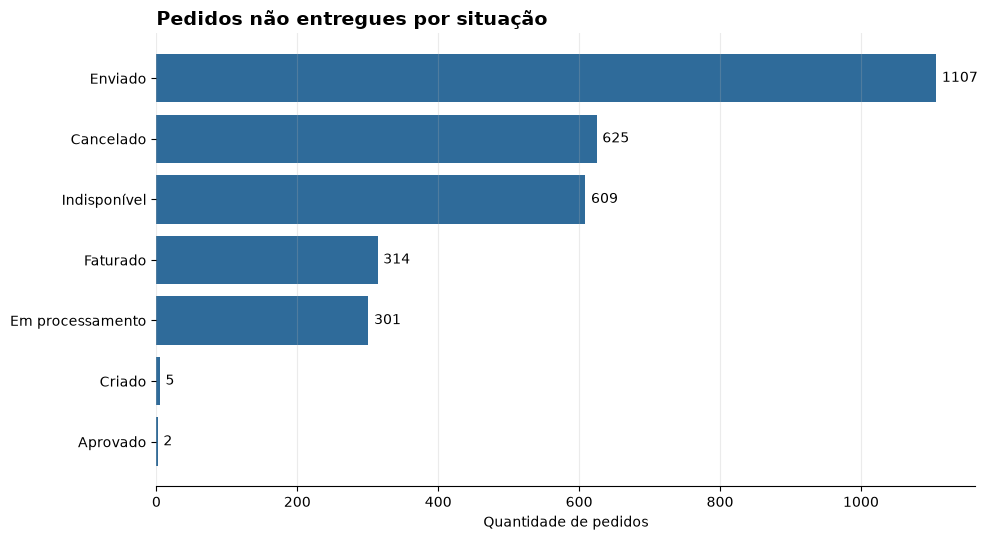

In [14]:
status_nao_entregues = (
    distribuicao_status
    .loc[distribuicao_status["status_original"] != "delivered"]
    .sort_values("quantidade", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5.5))

barras = ax.barh(
    status_nao_entregues["situacao"],
    status_nao_entregues["quantidade"],
    color="#2F6B9A"
)

ax.bar_label(barras, padding=4)

ax.set_title(
    "Pedidos não entregues por situação",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Quantidade de pedidos")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)

for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretação

Dos 99.441 pedidos, 2.963 (2,98%) não estavam classificados como entregues. A situação mais frequente nesse grupo foi “Enviado”, com 1.107 pedidos, indicando que parte deles ainda poderia estar em trânsito no momento da extração dos dados.

Os pedidos cancelados e indisponíveis somam 1.234 registros, representando aproximadamente 41,65% dos pedidos não entregues. Esses dois grupos merecem atenção porque indicam perdas efetivas ou possíveis problemas de disponibilidade e conclusão das compras.